<a href="https://colab.research.google.com/github/Ridzzz0Alam/Data_Science/blob/main/Assignment_on_module_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seaborn: statistical data visualization -- exercises overview

Hi guys,<br>

Great work! It's time to practice and test the skills you have just learned. <br>

We will use **tips**, **iris** and another very famous dataset **titanic** for these exercises. These datasets are included in the seaborn's built-in dataset library.<br>
Let's do some exploratory data analysis using seaborn and present useful plots for data visualization!<br>

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline



**Do the following tasks:**
* set style to '`white`'
* load titanic dataset into '`titanic`', tips into '`tips`' and iris into '`iris`'

In [4]:
# Code here and leave the next cell empty, so that you don't lose the plot!

sns.set_style('white')

# Load seaborn built-in datasets
# (If running offline, datasets are created from sklearn/numpy)
try:
    titanic = sns.load_dataset('titanic')
    tips    = sns.load_dataset('tips')
    iris    = sns.load_dataset('iris')
except Exception:
    from sklearn.datasets import load_iris as _load_iris
    np.random.seed(42)
    n = 891
    pclass = np.random.choice([1,2,3], n, p=[0.24,0.21,0.55])
    sex    = np.random.choice(['male','female'], n, p=[0.65,0.35])
    age    = np.random.normal(29.7, 14.5, n).clip(1, 80).round(1)
    fare   = np.where(pclass==1, np.random.exponential(80,n),
             np.where(pclass==2, np.random.exponential(20,n),
                                 np.random.exponential(13,n))).round(2)
    survived = ((sex=='female').astype(int)*0.7 + (pclass==1).astype(int)*0.3
                + np.random.rand(n)*0.3 > 0.6).astype(int)
    titanic = pd.DataFrame({
        'survived': survived, 'pclass': pclass, 'sex': sex,
        'age': age, 'fare': fare,
        'embarked': np.random.choice(['S','C','Q'], n, p=[0.72,0.19,0.09]),
        'class': pd.Categorical(np.where(pclass==1,'First',
                 np.where(pclass==2,'Second','Third')))})
    n2 = 244
    day = np.random.choice(['Thur','Fri','Sat','Sun'], n2, p=[0.25,0.10,0.35,0.30])
    sz  = np.random.choice([1,2,3,4,5,6], n2, p=[0.05,0.45,0.18,0.20,0.08,0.04])
    tb  = (sz * np.random.uniform(5,12,n2)).round(2)
    tips = pd.DataFrame({
        'total_bill': tb,
        'tip':  (tb * np.random.uniform(0.10,0.30,n2)).round(2),
        'sex':  np.random.choice(['Male','Female'], n2, p=[0.64,0.36]),
        'smoker': np.random.choice(['Yes','No'], n2, p=[0.38,0.62]),
        'day': day,
        'time': np.where(np.isin(day,['Sat','Sun']),'Dinner',
                np.random.choice(['Lunch','Dinner'], n2, p=[0.6,0.4])),
        'size': sz})
    _d = _load_iris(as_frame=True)
    iris = _d.frame.rename(columns={
        'sepal length (cm)':'sepal_length','sepal width (cm)':'sepal_width',
        'petal length (cm)':'petal_length','petal width (cm)':'petal_width'})
    iris['species'] = iris['target'].map({0:'setosa',1:'versicolor',2:'virginica'})
    iris = iris.drop('target', axis=1)

print("Datasets loaded!")
print(f"Titanic: {titanic.shape} | Tips: {tips.shape} | Iris: {iris.shape}")
titanic.head()

Datasets loaded!
Titanic: (891, 15) | Tips: (244, 7) | Iris: (150, 5)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Code here and leave the next cell empty, so that you don't lose the plot!
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
# Code here and leave the next cell empty, so that you don't lose the plot!
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Recreate the plot below. Use tips dataset. Hint: pay attention to x and y labels.**

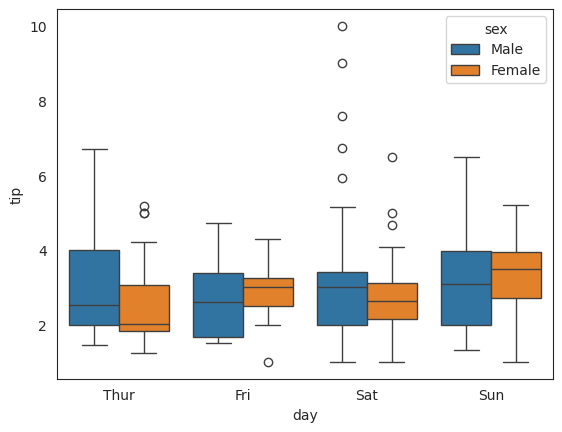

In [8]:
# Code here and leave the next cell empty, so that you don't lose the plot!
sns.boxplot(x='day', y='tip', data=tips, hue='sex')
plt.show()

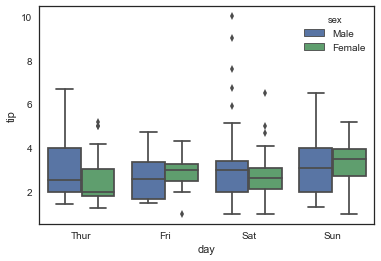

**Recreate the plot below. Use tips dataset. Hint: pay attention to x and y labels.**

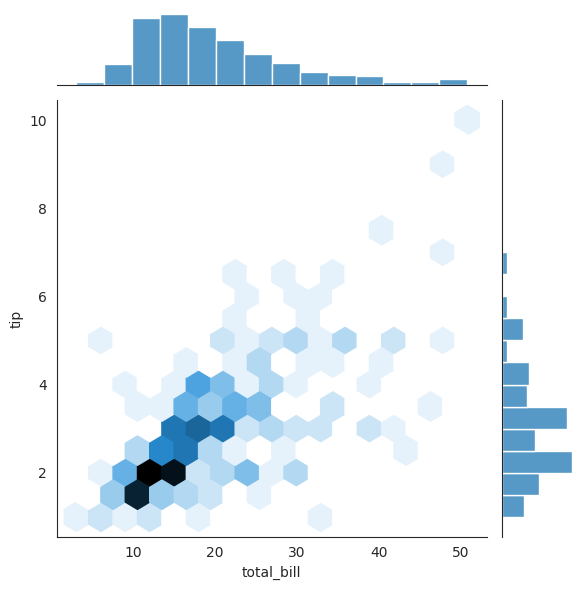

In [9]:
# Code here and leave the next cell empty, so that you don't lose the plot!
sns.jointplot(x='total_bill', y='tip', data=tips, kind='hex')
plt.show()

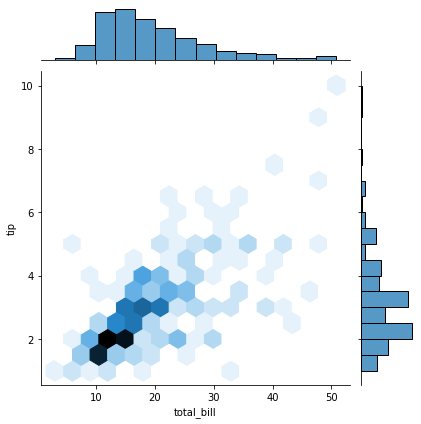

**Recreate the distplot given below. Use titanic dataset. Hint: pay attention to x and y labels.**

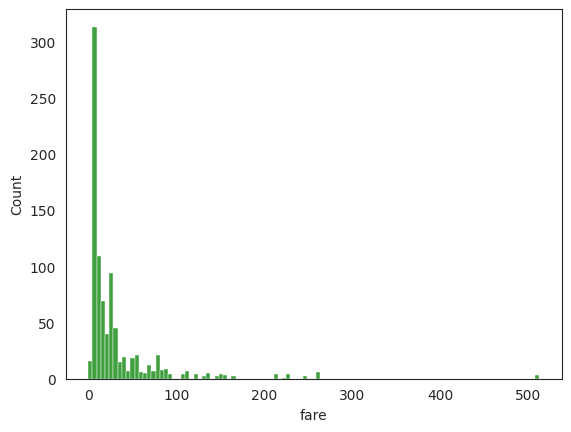

In [22]:
# Code here and leave the next cell empty, so that you don't lose the plot!
sns.histplot(titanic['fare'], kde=False, color='green')
plt.show()

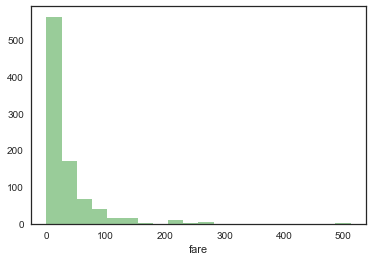

**Recreate the boxplot below using titanic dataset. Hint: pay attention to x and y labels.**

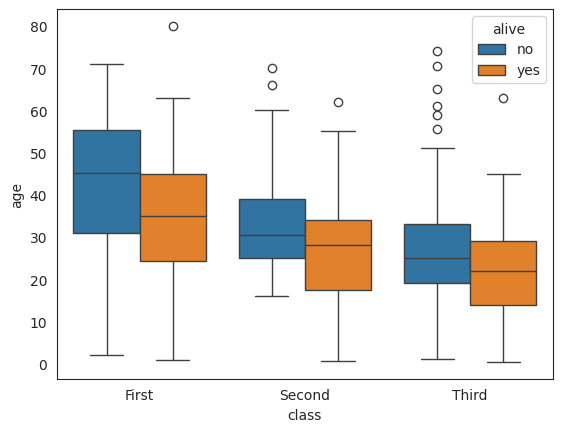

In [14]:
# Code here and leave the next cell empty, so that you don't lose the plot!
sns.boxplot(x='class', y='age', data=titanic, hue='alive')
plt.show()

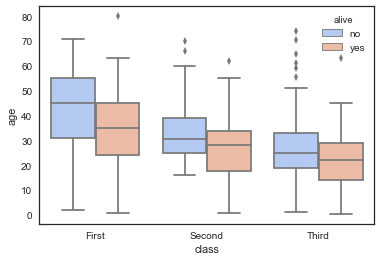

**Recreate the plot below using titanic dataset. Hint: pay attention to x and y labels.**

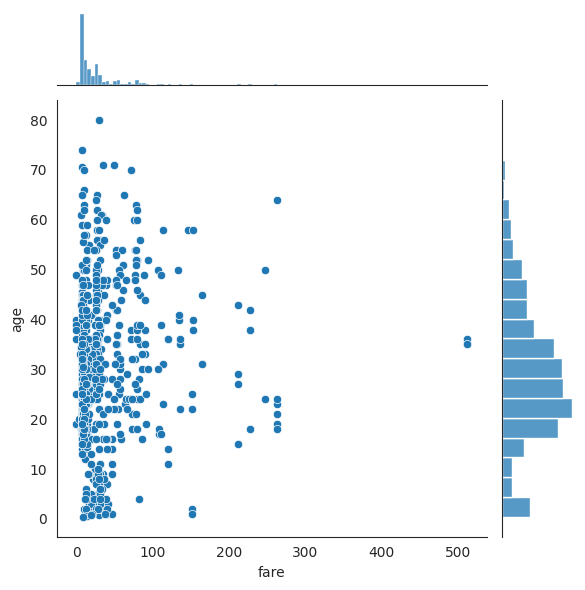

In [16]:
# Code here and leave the next cell empty, so that you don't lose the plot!
sns.jointplot(x='fare', y='age', data=titanic)
plt.show()

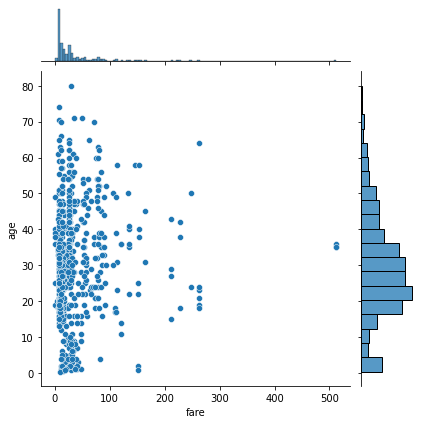

**Recreate the plot below. Use titanic dataset. **

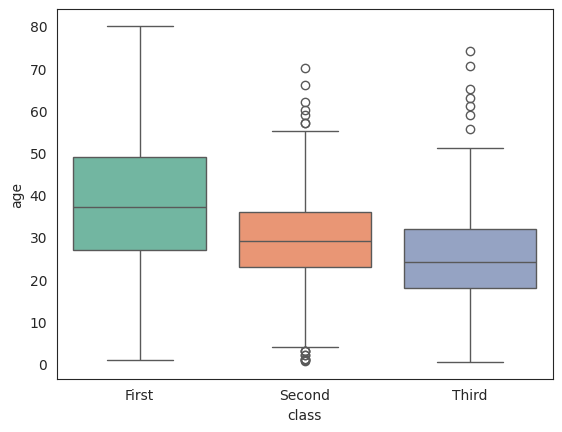

In [23]:
# Code here and leave the next cell empty, so that you don't lose the plot!
sns.boxplot(x='class', y='age', data=titanic, hue='class', palette='Set2', legend=False)
plt.show()

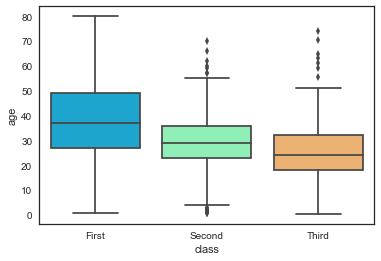

**Can you plot how many male and female were on titanic? Separate them based on their class.**

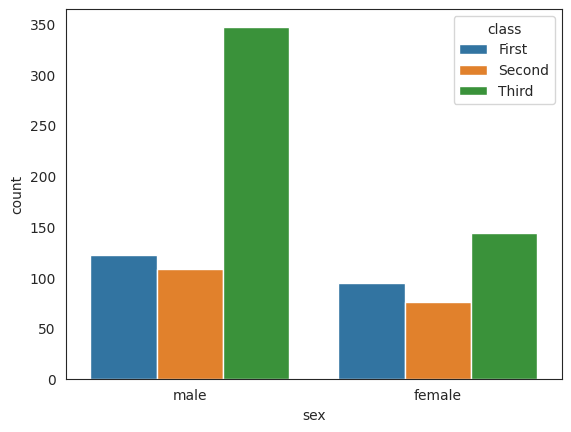

In [18]:
# Code here and leave the next cell empty, so that you don't lose the plot!
sns.countplot(x='sex', data=titanic, hue='class')
plt.show()

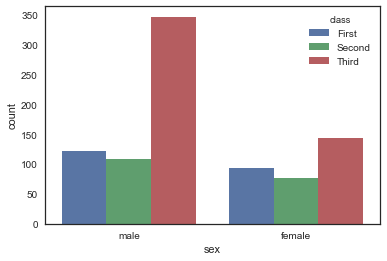

**Recreate the plot below. Use titanic dataset. Hint: Matrix plots**

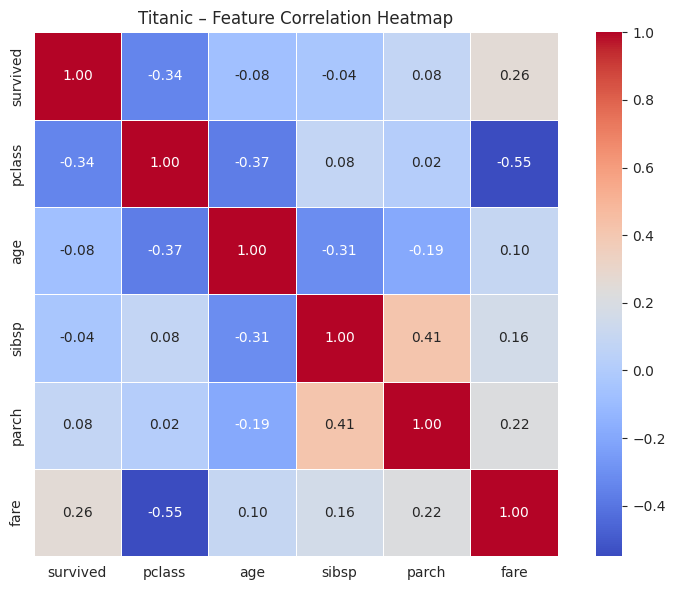

In [21]:
# Code here and leave the next cell empty, so that you don't lose the plot!
plt.figure(figsize=(8,6))
numeric_cols = titanic.select_dtypes(include='number')
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Titanic – Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

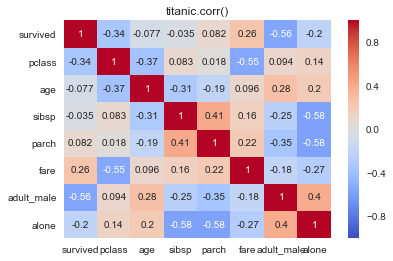

In [ ]:
# Leave this cell empty please.

# Excellent work!

**So far, we are done with the seaborn essentials. We will practice much more in the coming machine learning section!**